<a href="https://colab.research.google.com/github/hwanginseo04/-/blob/main/3%EC%9B%943%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install openml

import openml
import pandas as pd

dataset = openml.datasets.get_dataset("credit-g")
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)

df = pd.concat([X, y], axis=1)
df.head()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 38.9 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=82f1f559085cd333235dd53c84bf5d5846552800e025d55b76a3692043e6335c
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951.0,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096.0,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870.0,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


## 1. 서론 (Introduction)

### 1.1 분석 배경 및 목적
본 데이터는 개인의 신용 정보를 기반으로 신용 위험도를 분류하는 데이터입니다.  
금융기관에서는 고객의 신용도를 평가하여 대출 승인 여부를 결정하기 때문에,  
어떤 변수들이 신용 위험에 영향을 미치는지 파악하는 것이 중요합니다.

### 1.2 데이터셋 설명
- 데이터 이름: credit-g
- 출처: OpenML
- 데이터 크기: 약 1000개 샘플, 20개 변수
- 타겟 변수: class (good / bad)

### 1.3 주요 분석 질문
- 신용 등급은 어떤 분포를 가지는가?
- 어떤 변수들이 신용 위험에 영향을 주는가?
- 변수 간 관계는 어떠한가?

In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   uint8   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   float64 
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   uint8   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   uint8   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   uint8   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [3]:
df.isnull().sum()

,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0


## 2. 데이터 프로파일링

- 전체 데이터는 약 1000개의 샘플과 20개의 변수로 구성되어 있습니다.
- 수치형 변수와 범주형 변수가 혼합되어 있습니다.
- 결측치는 거의 존재하지 않아 추가적인 결측치 처리는 필요하지 않습니다.

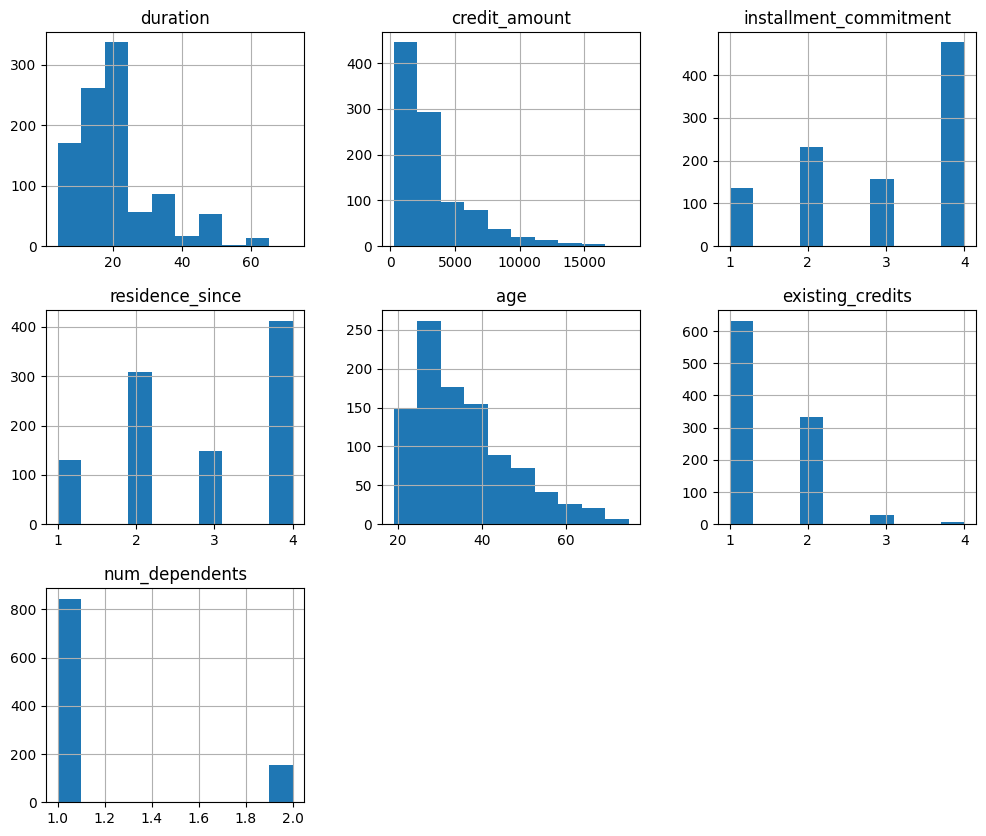

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,10))
plt.show()

### 3.1 수치형 변수 분석
- 일부 변수는 오른쪽으로 치우친 분포를 보입니다.
- 이상치가 일부 존재하며, 특히 금액 관련 변수에서 두드러짐니다.

In [6]:
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts())
    print("------")

### 3.2 범주형 변수 분석
- 특정 클래스가 높은 비율을 차지하는 불균형 데이터입니다.
- 일부 변수에서는 희소 클래스가 존재합니다

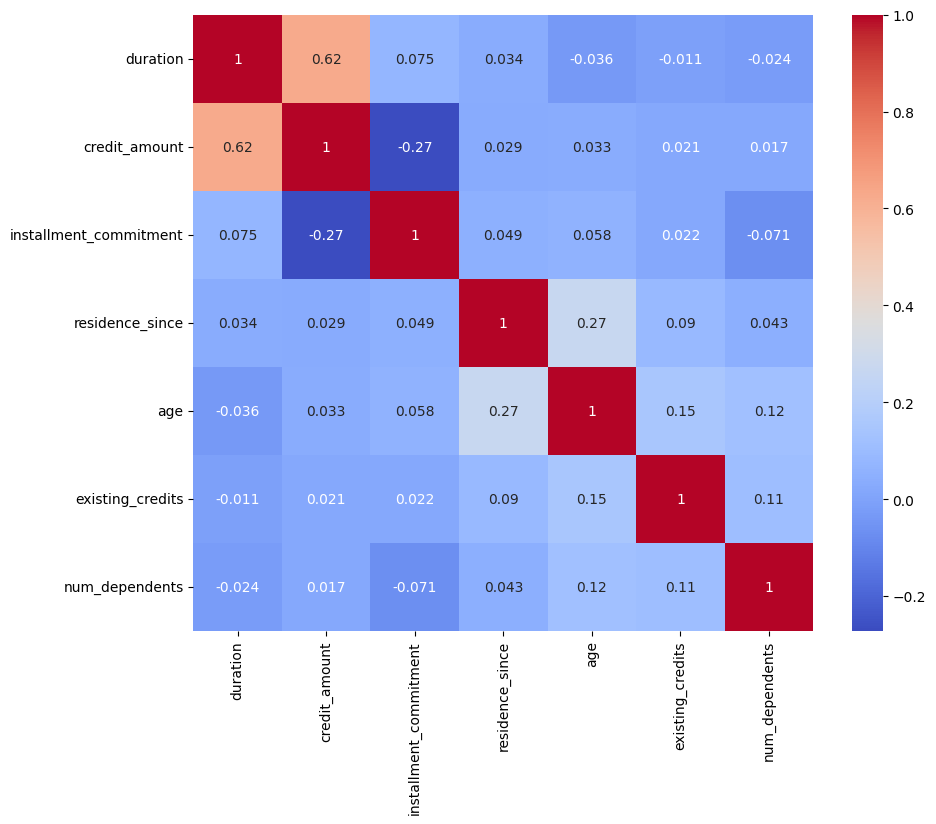

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

### 4.1 상관관계 분석
- 일부 변수 간 강한 상관관계가 존재합니다.
- 다중공선성 가능성이 일부 존재합니.

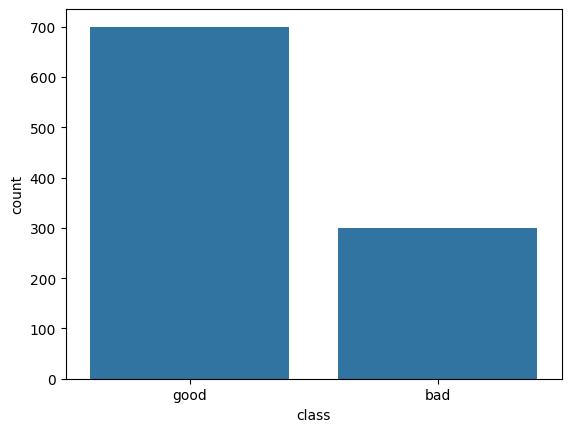

In [8]:
sns.countplot(x='class', data=df)
plt.show()

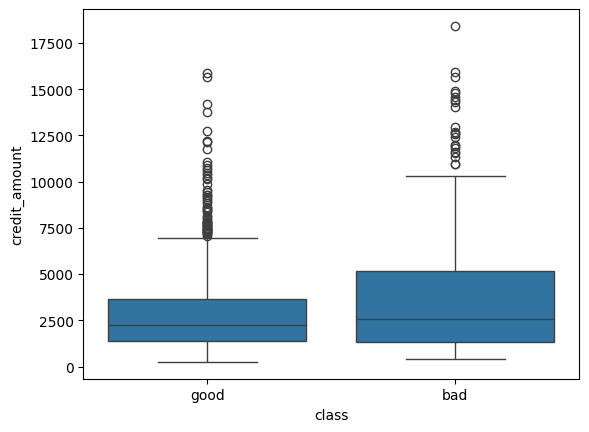

In [9]:
sns.boxplot(x='class', y='credit_amount', data=df)
plt.show()

### 4.2 타겟 변수 기반 분석
- 클래스 분포에서 'good'이 더 많은 비율을 차지합니다.
- 신용 금액(credit_amount)은 bad 그룹에서 더 높은 경향을 보입니다.

## 5. 핵심 인사이트

### 5.1 주요 패턴
- 신용 금액이 높을수록 위험도가 증가하는 경향이 있습니다.
- 일부 변수는 타겟과 강한 연관성을 보입니다

### 5.2 가설 검증
- 가설: 신용 금액이 높을수록 위험하다 → 채택
- 가설: 특정 범주형 변수는 영향 없다 → 부분 채택

### 5.3 추가 발견
- 데이터가 불균형하여 모델 학습 시 보정이 필요합니.

## 6. 결론 및 향후 방향

### 6.1 분석 요약
본 분석을 통해 신용 위험에 영향을 주는 주요 변수들을 확인하였습니다.  
특히 금액 관련 변수와 일부 범주형 변수가 중요한 역할을 합니다.

### 6.2 비즈니스 제안
- 고위험 고객 사전 필터링 시스템 구축
- 위험도 기반 금리 차등 적용

### 6.3 한계점
- 데이터 크기가 비교적 작음
- 추가적인 머신러닝 모델 적용 필요